In [2]:
%%bash
#------------------------------------------
# Descargo dataset
#------------------------------------------

CARPETA1="DocExplore_images"
CARPETA2="DocExplore_queries_web"
ARCHIVO_TEMP="DocExplore_temp.zip"
URL="http://201.238.213.114:2280/sketchapp/get_files/DocExplore"

# Verifica si ambas carpetas ya existen
if [ -d "$CARPETA1" ] && [ -d "$CARPETA2" ]; then
    echo "Las carpetas '$CARPETA1' y '$CARPETA2' ya existen. Omitiendo descarga."
else
    echo "Falta una o ambas carpetas. Iniciando descarga..."
    
    # 1. Descarga el archivo
    wget -q --show-progress $URL -O $ARCHIVO_TEMP
    
    # 2. Descomprime el archivo
    echo "Descomprimiendo..."
    unzip -q $ARCHIVO_TEMP
    
    # 3. Elimina el archivo comprimido
    echo "Eliminando archivo temporal..."
    rm $ARCHIVO_TEMP
    
    echo "¡Listo! Archivos preparados."
fi

Las carpetas 'DocExplore_images' y 'DocExplore_queries_web' ya existen. Omitiendo descarga.


In [3]:
%%bash
#------------------------------------------
#Descargo modelo
#------------------------------------------

REPO_URL="https://github.com/mpizarrot/iDoc.git"
CARPETA="iDoc"

# Verifica si la carpeta del repositorio ya existe
if [ -d "$CARPETA" ]; then
    echo "La carpeta '$CARPETA' ya existe. Omitiendo la descarga del modelo."
else
    echo "Descargando (clonando) el modelo desde GitHub..."
    git clone $REPO_URL
    echo "¡Listo! Repositorio descargado exitosamente."
fi

La carpeta 'iDoc' ya existe. Omitiendo la descarga del modelo.


In [4]:
%%bash
#------------------------------------------
# Descargo pesos del modelo (checkpoint)
#------------------------------------------

ARCHIVO="skDinoV3_sketchy.ckpt"
URL="http://201.238.213.114:2280/sketchapp/get_files/skDinoV3_sketchy.ckpt"

# Verifica si el archivo ya existe (-f evalúa archivos, no carpetas)
if [ -f "$ARCHIVO" ]; then
    echo "El archivo '$ARCHIVO' ya existe. Omitiendo descarga."
else
    echo "El archivo no existe. Iniciando descarga..."
    
    # Descarga el archivo
    wget -q --show-progress $URL -O $ARCHIVO
    
    echo "¡Listo! Archivo descargado exitosamente."
fi

El archivo 'skDinoV3_sketchy.ckpt' ya existe. Omitiendo descarga.


In [5]:
%%bash
#------------------------------------------
# Clono el repo base
#------------------------------------------

CARPETA="S3BIR-DINO"
REPO_URL="https://github.com/mpizarrot/S3BIR-DINO.git"

# Verifica si la carpeta del repositorio ya existe
if [ -d "$CARPETA" ]; then
    echo "La carpeta '$CARPETA' ya existe. Omitiendo la clonación."
else
    echo "La carpeta no existe. Iniciando clonación desde GitHub..."
    
    # Clona el repositorio
    git clone $REPO_URL
    
    echo "¡Listo! Repositorio descargado."
fi

La carpeta no existe. Iniciando clonación desde GitHub...


Cloning into 'S3BIR-DINO'...


¡Listo! Repositorio descargado.


In [6]:
!mv S3BIR-DINO S3BIR_DINO

In [7]:
import torch
from S3BIR_DINO.dinov3_model import S3birDinov3

ckpt_path = "skDinoV3_sketchy.ckpt" #"s3bir_dinov2_flickr.ckpt"
checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
state_dict = checkpoint.get("state_dict", checkpoint)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = S3birDinov3().to(device)
model.load_state_dict(state_dict)
model.eval()

print("Model loaded and set to eval mode.")

Model loaded and set to eval mode.


In [8]:
!pip install tqdm

In [9]:
# ========================================================
# CELDA 1: Extracción de embeddings
# ========================================================

import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from pathlib import Path
from datetime import datetime
from tqdm import tqdm

IMAGE_DIR   = Path("DocExplore_queries_web")
SKETCH_DIR  = Path("Sketches")
OUTPUT_FILE = Path("embeddings.pt")

SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def safe_load(path):
    try:
        return Image.open(path).convert("RGB")
    except Exception as e:
        print(f"  [WARN] {path.name}: {e}")
        return None

def embed_files(file_paths, dtype, desc):
    records = []
    for i in tqdm(range(0, len(file_paths), BATCH_SIZE), desc=desc):
        batch_paths = file_paths[i : i + BATCH_SIZE]
        tensors, valid_paths = [], []
        for p in batch_paths:
            img = safe_load(p)
            if img is None: continue
            tensors.append(transform(img))
            valid_paths.append(p)
        if not tensors: continue

        batch_tensor = torch.stack(tensors).to(device)
        with torch.no_grad():
            embeddings = model(batch_tensor, dtype=dtype)
            embeddings = F.normalize(embeddings, dim=1)  # L2-norm → cosine = dot product

        for path, emb in zip(valid_paths, embeddings):
            # Categoría: subcarpeta para imágenes, prefijo del nombre para sketches
            if dtype == "image":
                category = path.parent.name
            else:
                # Nombre típico: "sketch_1_DocExplore_bateau_1349_4x_1349.jpeg"
                # Extrae la parte después de "DocExplore_" si existe, sino usa la carpeta padre
                name = path.stem.lower()
                if "docexplore_" in name:
                    category = name.split("docexplore_")[1].split("_")[0]
                else:
                    category = path.parent.name

            records.append({
                "path"      : str(path),
                "filename"  : path.name,
                "stem"      : path.stem,
                "category"  : category,
                "dtype"     : dtype,
                "embedding" : emb.cpu(),
            })
    return records

image_paths  = sorted([p for p in IMAGE_DIR.rglob("*")  if p.suffix.lower() in SUPPORTED_EXTS])
sketch_paths = sorted([p for p in SKETCH_DIR.rglob("*") if p.suffix.lower() in SUPPORTED_EXTS])
print(f"Imágenes encontradas : {len(image_paths)}")
print(f"Sketches encontrados : {len(sketch_paths)}")

image_records  = embed_files(image_paths,  dtype="image",  desc="Imágenes ")
sketch_records = embed_files(sketch_paths, dtype="sketch", desc="Sketches ")

torch.save({
    "metadata": {
        "created_at"   : datetime.now().isoformat(),
        "model_ckpt"   : ckpt_path,
        "n_images"     : len(image_records),
        "n_sketches"   : len(sketch_records),
        "embedding_dim": image_records[0]["embedding"].shape[0] if image_records else None,
        "normalized"   : True,
    },
    "records": image_records + sketch_records,
}, OUTPUT_FILE)

print(f"\n✅ Guardado en '{OUTPUT_FILE}'")
print(f"   {len(image_records)} imágenes | {len(sketch_records)} sketches | dim=768 | L2-norm")

Imágenes encontradas : 1447
Sketches encontrados : 456


Sketches : 100%|██████████| 15/15 [00:01<00:00, 11.02it/s]


✅ Guardado en 'embeddings.pt'
   1447 imágenes | 456 sketches | dim=768 | L2-norm


In [10]:
# ========================================================
# CELDA 2: Construcción de matrices y ranking
# ========================================================

import torch
import numpy as np

data     = torch.load(OUTPUT_FILE, weights_only=False)
records  = data["records"]
metadata = data["metadata"]

sketches = [r for r in records if r["dtype"] == "sketch"]
images   = [r for r in records if r["dtype"] == "image"]

print(f"Sketches (queries) : {len(sketches)}")
print(f"Imágenes (gallery) : {len(images)}")
print(f"Embedding dim      : {metadata['embedding_dim']}")
print(f"Categorías únicas  : {sorted(set(r['category'] for r in records))}")

# Matrices de embeddings [N, D]
S = torch.stack([r["embedding"] for r in sketches])  # [Q, D]
I = torch.stack([r["embedding"] for r in images])    # [G, D]

# Similitud coseno = producto punto (ya están L2-normalizados)
sim_matrix = S @ I.T   # [Q, G]

# Rankings: para cada query, índices de imágenes ordenadas de mayor a menor similitud
rankings = torch.argsort(sim_matrix, dim=1, descending=True)  # [Q, G]

print(f"\nMatriz de similitud : {tuple(sim_matrix.shape)}  (queries × gallery)")
print(f"Rango de valores    : [{sim_matrix.min():.4f}, {sim_matrix.max():.4f}]")

Sketches (queries) : 456
Imágenes (gallery) : 1447
Embedding dim      : 768
Categorías únicas  : ['BP', 'D', 'S', 'T', 'bateau', 'bateau_d', 'bateau_g', 'bp', 'croix', 'd', 'double', 'double_sep', 'encadrement', 'grand', 'grand_A', 'henri', 'henri_d', 'henri_g', 'losange', 'marqeur', 'obj', 'obj_1', 'obj_2', 'obj_3', 'obj_31', 'obj_34', 'obj_35', 'obj_36', 'obj_37', 'obj_38', 'obj_39', 'obj_40', 'obj_42', 'obj_61', 'pdp', 'petit', 'petit_A', 'rubanlettrine', 'rubanlettrine_b', 's', 'simple', 'simple_sep', 'status', 't', 'triple', 'triple_sep']

Matriz de similitud : (456, 1447)  (queries × gallery)
Rango de valores    : [-0.2021, 0.8315]


In [11]:
# ========================================================
# CELDA 3: Cálculo de AP por query y mAP global
# ========================================================

def average_precision(ranked_labels: np.ndarray) -> float:
    """AP estándar: promedio de precision@k solo en posiciones relevantes."""
    relevant = ranked_labels.astype(float)
    n_relevant = relevant.sum()
    if n_relevant == 0:
        return 0.0
    cumsum    = np.cumsum(relevant)
    positions = np.arange(1, len(relevant) + 1)
    precisions_at_k = cumsum / positions
    return float((precisions_at_k * relevant).sum() / n_relevant)

ap_per_query  = []
results_table = []

for q_idx, sketch in enumerate(sketches):
    q_cat     = sketch["category"]
    rank_idxs = rankings[q_idx].numpy()

    # Etiqueta 1 si la imagen es de la misma categoría que el sketch
    ranked_labels = np.array([
        1 if images[i]["category"] == q_cat else 0
        for i in rank_idxs
    ])

    n_relevant = ranked_labels.sum()
    ap = average_precision(ranked_labels)
    ap_per_query.append(ap)

    results_table.append({
        "query"      : sketch["filename"],
        "category"   : q_cat,
        "n_relevant" : int(n_relevant),
        "AP"         : ap,
        "top1_hit"   : bool(ranked_labels[0]),
        "top5_hits"  : int(ranked_labels[:5].sum()),
        "top10_hits" : int(ranked_labels[:10].sum()),
    })

mAP = float(np.mean(ap_per_query))

print(f"{'='*45}")
print(f"  mAP global : {mAP:.4f}  ({mAP*100:.2f}%)")
print(f"{'='*45}")
print(f"  Queries evaluadas : {len(ap_per_query)}")
print(f"  AP máximo         : {max(ap_per_query):.4f}")
print(f"  AP mínimo         : {min(ap_per_query):.4f}")
print(f"  AP mediana        : {np.median(ap_per_query):.4f}")
top1_acc = np.mean([r["top1_hit"] for r in results_table])
print(f"  Top-1 accuracy    : {top1_acc:.4f}  ({top1_acc*100:.2f}%)")

  mAP global : 0.4694  (46.94%)
  Queries evaluadas : 456
  AP máximo         : 1.0000
  AP mínimo         : 0.0000
  AP mediana        : 0.5784
  Top-1 accuracy    : 0.5219  (52.19%)


/tmp/ipykernel_270527/3080672275.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap("tab10", len(unique_cats))
/tmp/ipykernel_270527/3080672275.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


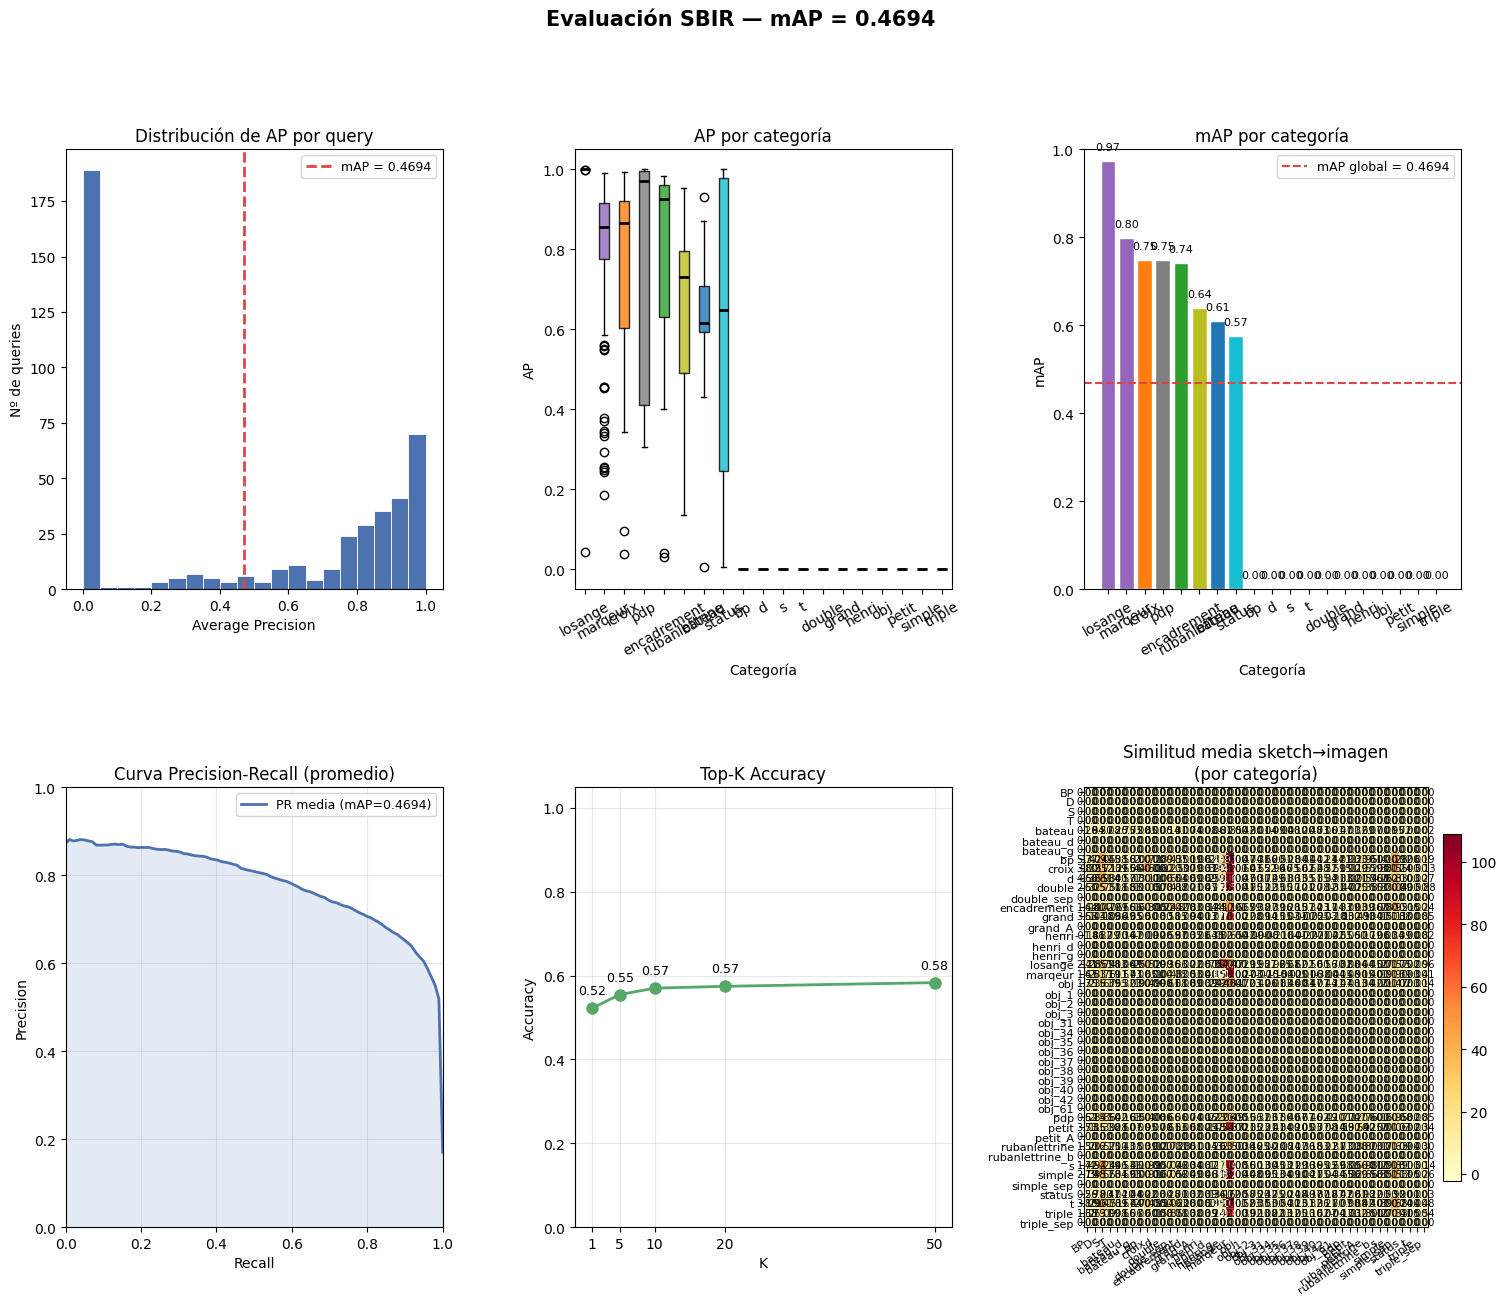

📊 Figura guardada en 'sbir_evaluation.png'


In [12]:
# ========================================================
# CELDA 4: Visualizaciones
# ========================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict

ap_values  = np.array(ap_per_query)
categories = [r["category"] for r in results_table]

# ── Paleta de categorías ──────────────────────────────────
unique_cats = sorted(set(
    [r["category"] for r in sketches] + [r["category"] for r in images]
))
cmap        = plt.cm.get_cmap("tab10", len(unique_cats))
cat_color   = {c: cmap(i) for i, c in enumerate(unique_cats)}

fig = plt.figure(figsize=(18, 14))
fig.suptitle(f"Evaluación SBIR — mAP = {mAP:.4f}", fontsize=15, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Distribución de AP (histograma) ───────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ap_values, bins=20, color="#4C72B0", edgecolor="white", linewidth=0.6)
ax1.axvline(mAP, color="#DD4444", linewidth=2, linestyle="--", label=f"mAP = {mAP:.4f}")
ax1.set_title("Distribución de AP por query")
ax1.set_xlabel("Average Precision")
ax1.set_ylabel("Nº de queries")
ax1.legend(fontsize=9)

# ── 2. AP por categoría (boxplot) ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cat_aps = defaultdict(list)
for r in results_table:
    cat_aps[r["category"]].append(r["AP"])
sorted_cats = sorted(cat_aps, key=lambda c: np.mean(cat_aps[c]), reverse=True)
bp = ax2.boxplot(
    [cat_aps[c] for c in sorted_cats],
    labels=sorted_cats,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
)
for patch, cat in zip(bp["boxes"], sorted_cats):
    patch.set_facecolor(cat_color[cat])
    patch.set_alpha(0.8)
ax2.set_title("AP por categoría")
ax2.set_xlabel("Categoría")
ax2.set_ylabel("AP")
ax2.tick_params(axis="x", rotation=30)

# ── 3. mAP por categoría (barras) ────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cat_map   = {c: np.mean(cat_aps[c]) for c in sorted_cats}
bar_colors = [cat_color[c] for c in sorted_cats]
bars = ax3.bar(sorted_cats, [cat_map[c] for c in sorted_cats], color=bar_colors, edgecolor="white")
ax3.axhline(mAP, color="#DD4444", linewidth=1.5, linestyle="--", label=f"mAP global = {mAP:.4f}")
ax3.set_title("mAP por categoría")
ax3.set_xlabel("Categoría")
ax3.set_ylabel("mAP")
ax3.set_ylim(0, 1)
ax3.tick_params(axis="x", rotation=30)
ax3.legend(fontsize=9)
for bar, cat in zip(bars, sorted_cats):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{cat_map[cat]:.2f}", ha="center", va="bottom", fontsize=8)

# ── 4. Precision-Recall curve promedio ───────────────────
ax4 = fig.add_subplot(gs[1, 0])
max_gallery = len(images)
pr_curves   = []
for q_idx in range(len(sketches)):
    q_cat        = sketches[q_idx]["category"]
    rank_idxs    = rankings[q_idx].numpy()
    ranked_labels = np.array([1 if images[i]["category"] == q_cat else 0 for i in rank_idxs])
    n_rel        = ranked_labels.sum()
    if n_rel == 0: continue
    tp           = np.cumsum(ranked_labels)
    precision    = tp / np.arange(1, len(ranked_labels) + 1)
    recall       = tp / n_rel
    pr_curves.append((recall, precision))

# Interpola todas a recall común
recall_common = np.linspace(0, 1, 100)
interp_precs  = []
for rec, prec in pr_curves:
    interp_precs.append(np.interp(recall_common, rec, prec))
mean_prec = np.mean(interp_precs, axis=0)

ax4.plot(recall_common, mean_prec, color="#4C72B0", linewidth=2, label=f"PR media (mAP={mAP:.4f})")
ax4.fill_between(recall_common, mean_prec, alpha=0.15, color="#4C72B0")
ax4.set_title("Curva Precision-Recall (promedio)")
ax4.set_xlabel("Recall")
ax4.set_ylabel("Precision")
ax4.set_xlim(0, 1); ax4.set_ylim(0, 1)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ── 5. Top-K accuracy ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ks   = [1, 5, 10, 20, 50]
topk_accs = []
for k in ks:
    hits = []
    for q_idx in range(len(sketches)):
        q_cat      = sketches[q_idx]["category"]
        rank_idxs  = rankings[q_idx].numpy()[:k]
        hit        = any(images[i]["category"] == q_cat for i in rank_idxs)
        hits.append(int(hit))
    topk_accs.append(np.mean(hits))

ax5.plot(ks, topk_accs, "o-", color="#55A868", linewidth=2, markersize=8)
for k, acc in zip(ks, topk_accs):
    ax5.annotate(f"{acc:.2f}", (k, acc), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=9)
ax5.set_title("Top-K Accuracy")
ax5.set_xlabel("K")
ax5.set_ylabel("Accuracy")
ax5.set_ylim(0, 1.05)
ax5.set_xticks(ks)
ax5.grid(True, alpha=0.3)

# ── 6. Heatmap similitud media entre categorías ──────────
ax6 = fig.add_subplot(gs[1, 2])
n_cats = len(unique_cats)
heatmap = np.zeros((n_cats, n_cats))
for q_idx, sketch in enumerate(sketches):
    q_cat_idx = unique_cats.index(sketch["category"])
    sims      = sim_matrix[q_idx].numpy()
    for g_idx, image in enumerate(images):
        g_cat_idx = unique_cats.index(image["category"])
        heatmap[q_cat_idx, g_cat_idx] += sims[g_idx]

# Normalizar por número de elementos
for i, qc in enumerate(unique_cats):
    n_sketches_cat = sum(1 for s in sketches if s["category"] == qc)
    if n_sketches_cat > 0:
        heatmap[i] /= n_sketches_cat

im = ax6.imshow(heatmap, cmap="YlOrRd", aspect="auto")
ax6.set_xticks(range(n_cats)); ax6.set_xticklabels(unique_cats, rotation=35, ha="right", fontsize=8)
ax6.set_yticks(range(n_cats)); ax6.set_yticklabels(unique_cats, fontsize=8)
ax6.set_title("Similitud media sketch→imagen\n(por categoría)")
plt.colorbar(im, ax=ax6, fraction=0.046, pad=0.04)
for i in range(n_cats):
    for j in range(n_cats):
        ax6.text(j, i, f"{heatmap[i,j]:.2f}", ha="center", va="center",
                 fontsize=7, color="black" if heatmap[i,j] < heatmap.max()*0.7 else "white")

plt.savefig("sbir_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Figura guardada en 'sbir_evaluation.png'")

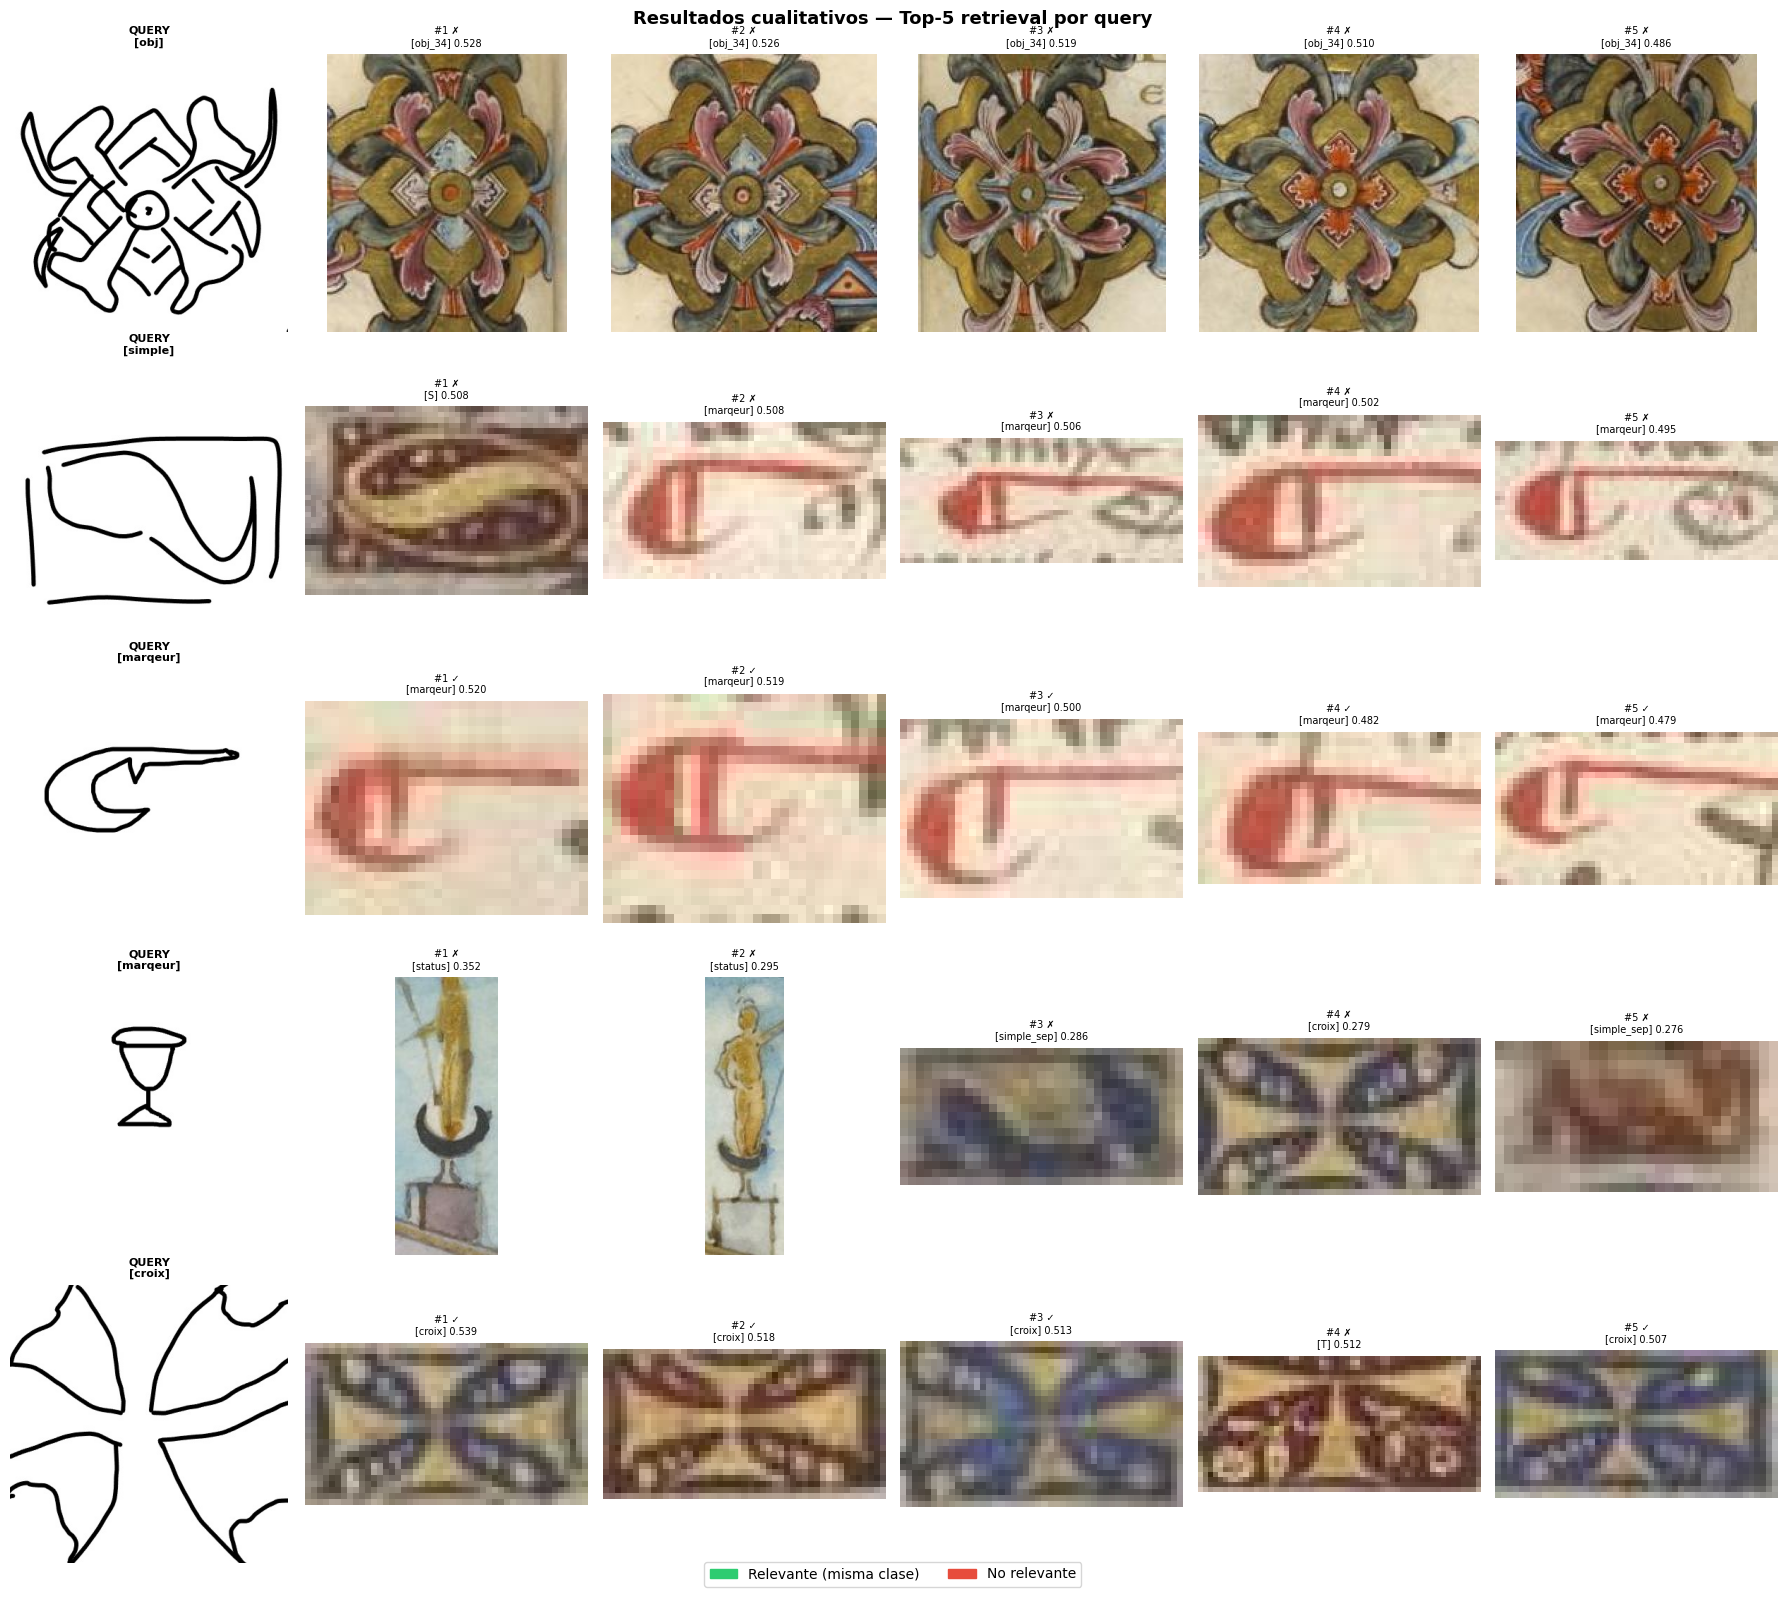

🖼️  Figura guardada en 'sbir_qualitative.png'


In [13]:
# ========================================================
# CELDA 5: Visualización cualitativa — top retrieval
# ========================================================

import random

N_QUERIES = 5   # cuántas queries mostrar (ajustable)

# Elige N_QUERIES queries al azar (una por categoría si hay suficientes)
sample_indices = random.sample(range(len(sketches)), min(N_QUERIES, len(sketches)))

TOP_K_SHOW = 5  # imágenes a mostrar por fila

fig, axes = plt.subplots(len(sample_indices), TOP_K_SHOW + 1,
                         figsize=(3 * (TOP_K_SHOW + 1), 3.2 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]

fig.suptitle("Resultados cualitativos — Top-5 retrieval por query", fontsize=13, fontweight="bold")

for row, q_idx in enumerate(sample_indices):
    sketch_rec  = sketches[q_idx]
    q_cat       = sketch_rec["category"]
    rank_idxs   = rankings[q_idx].numpy()
    ranked_sims = sim_matrix[q_idx].numpy()

    # Columna 0: sketch query
    ax = axes[row][0]
    try:
        ax.imshow(Image.open(sketch_rec["path"]).convert("RGB"))
    except:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center")
    ax.set_title(f"QUERY\n[{q_cat}]", fontsize=8, fontweight="bold")
    ax.axis("off")
    ax.patch.set_edgecolor("#333333"); ax.patch.set_linewidth(3)

    # Columnas 1…TOP_K_SHOW: imágenes recuperadas
    for col, rank_pos in enumerate(range(TOP_K_SHOW)):
        g_idx   = rank_idxs[rank_pos]
        img_rec = images[g_idx]
        g_cat   = img_rec["category"]
        sim_val = ranked_sims[g_idx]
        relevant = (g_cat == q_cat)

        ax = axes[row][col + 1]
        try:
            ax.imshow(Image.open(img_rec["path"]).convert("RGB"))
        except:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center")

        border_color = "#2ECC71" if relevant else "#E74C3C"
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4)

        label = "✓" if relevant else "✗"
        ax.set_title(f"#{rank_pos+1} {label}\n[{g_cat}] {sim_val:.3f}", fontsize=7)
        ax.axis("off")

green_patch = mpatches.Patch(color="#2ECC71", label="Relevante (misma clase)")
red_patch   = mpatches.Patch(color="#E74C3C", label="No relevante")
fig.legend(handles=[green_patch, red_patch], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig("sbir_qualitative.png", dpi=150, bbox_inches="tight")
plt.show()
print("🖼️  Figura guardada en 'sbir_qualitative.png'")

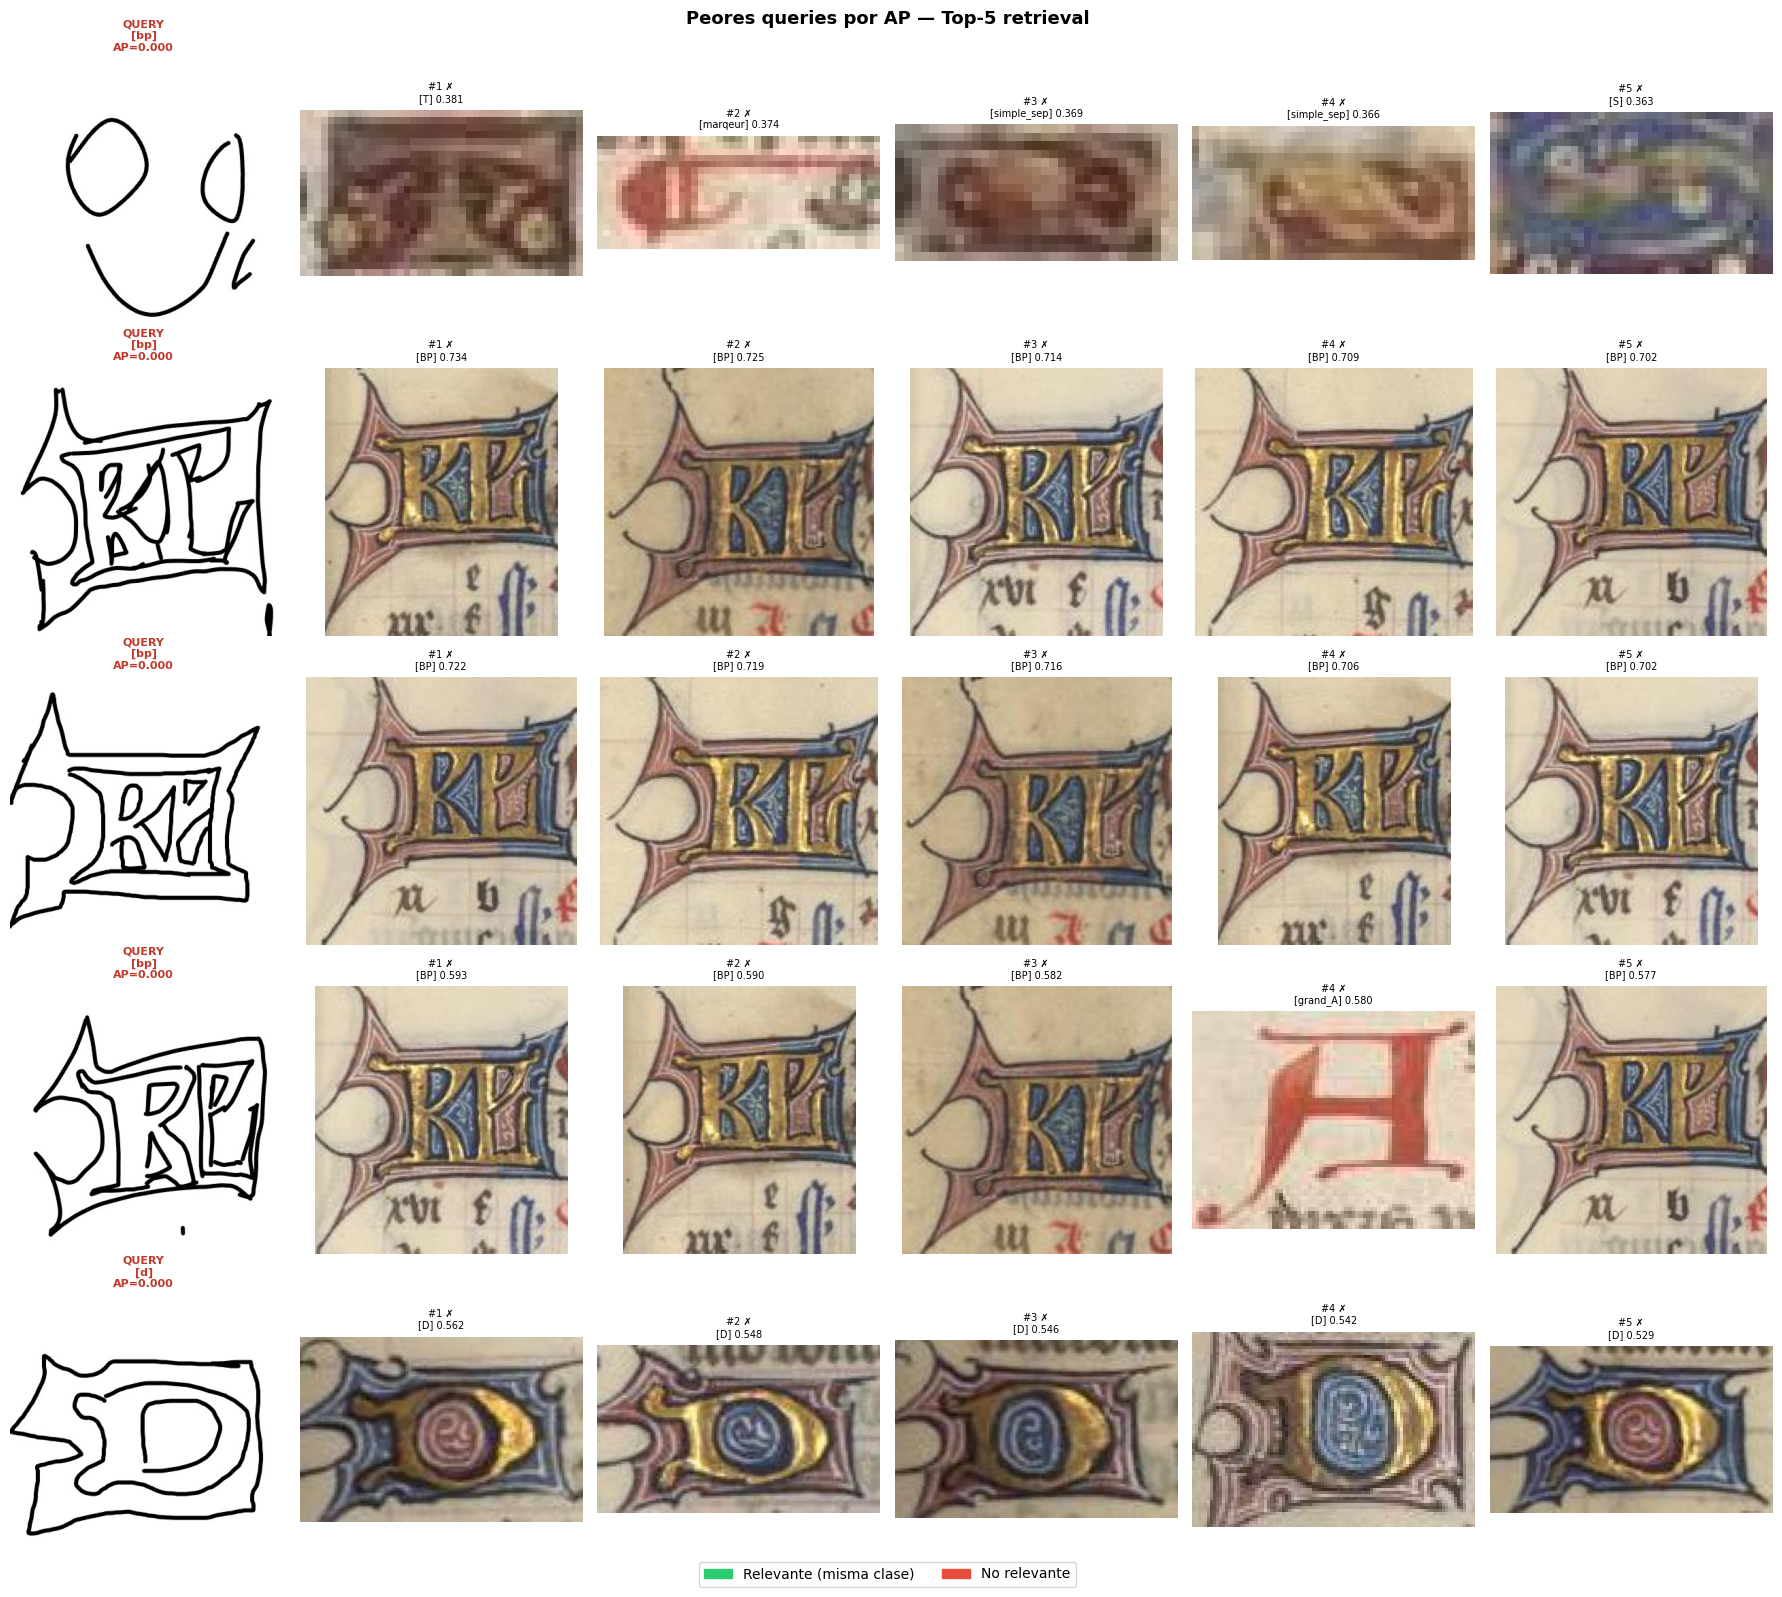

🖼️  Figura guardada en 'sbir_worst_queries.png'


In [14]:
# ========================================================
# CELDA 6: Visualización cualitativa — peores queries (menor AP)
# ========================================================

worst_indices = sorted(range(len(ap_per_query)), key=lambda i: ap_per_query[i])[:5]

TOP_K_SHOW = 5

fig, axes = plt.subplots(len(worst_indices), TOP_K_SHOW + 1,
                         figsize=(3 * (TOP_K_SHOW + 1), 3.2 * len(worst_indices)))
if len(worst_indices) == 1:
    axes = [axes]

fig.suptitle("Peores queries por AP — Top-5 retrieval", fontsize=13, fontweight="bold")

for row, q_idx in enumerate(worst_indices):
    sketch_rec  = sketches[q_idx]
    q_cat       = sketch_rec["category"]
    rank_idxs   = rankings[q_idx].numpy()
    ranked_sims = sim_matrix[q_idx].numpy()
    ap_val      = ap_per_query[q_idx]

    # Columna 0: sketch query
    ax = axes[row][0]
    try:
        ax.imshow(Image.open(sketch_rec["path"]).convert("RGB"))
    except:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center")
    ax.set_title(f"QUERY\n[{q_cat}]\nAP={ap_val:.3f}", fontsize=8, fontweight="bold", color="#C0392B")
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor("#C0392B")
        spine.set_linewidth(3)

    # Columnas 1…TOP_K_SHOW: imágenes recuperadas
    for col, rank_pos in enumerate(range(TOP_K_SHOW)):
        g_idx    = rank_idxs[rank_pos]
        img_rec  = images[g_idx]
        g_cat    = img_rec["category"]
        sim_val  = ranked_sims[g_idx]
        relevant = (g_cat == q_cat)

        ax = axes[row][col + 1]
        try:
            ax.imshow(Image.open(img_rec["path"]).convert("RGB"))
        except:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center")

        border_color = "#2ECC71" if relevant else "#E74C3C"
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4)

        label = "✓" if relevant else "✗"
        ax.set_title(f"#{rank_pos+1} {label}\n[{g_cat}] {sim_val:.3f}", fontsize=7)
        ax.axis("off")

green_patch = mpatches.Patch(color="#2ECC71", label="Relevante (misma clase)")
red_patch   = mpatches.Patch(color="#E74C3C", label="No relevante")
fig.legend(handles=[green_patch, red_patch], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig("sbir_worst_queries.png", dpi=150, bbox_inches="tight")
plt.show()
print("🖼️  Figura guardada en 'sbir_worst_queries.png'")